In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('cened_milano_pulito.csv')
df.head()

,RESIDENZIALE,NON_RESIDENZIALE,CLASSIFICAZIONE_DPR,INTERO_EDIFICIO,UNITA_IMMOBILIARE,NUMERO_UNITA_IMMOBILIARI,NUOVA_COSTRUZIONE,RISTRUTTURAZIONE_IMPORTANTE,RIQUALIFICAZIONE_ENERGETICA,COMUNE,...,CLIMATIZZAZIONE_ESTIVA,VENTILAZIONE_MECCANICA,PROD_ACQUA_CALDA_SANITARIA,VETTORE_ENERGETICO,CI_TIPO_IMPIANTO_1,CI_ANNO_INSTALLAZIONE_1,CI_VETTORE_ENERGETICO_1,CI_POTENZA_NOMINALE_1,CI_EFFICIENZA_MEDIA,CLASSE_BUONA
0,True,False,E.1(1),False,True,1,False,False,False,MILANO,...,False,False,True,NaN,Generatore a combustione,2006.0,Gas naturale,450.0,0.84,0
1,False,True,E.5,False,True,14,False,False,False,MILANO,...,False,False,False,NaN,NaN,NaN,NaN,NaN,0.73,0
2,True,False,E.1(1),False,True,1,False,False,False,MILANO,...,False,False,True,NaN,Generatore a combustione,2008.0,Gas naturale,6.0,0.74,0
3,True,False,E.1(1),False,True,1,False,False,False,MILANO,...,True,False,True,NaN,Teleriscaldamento,1997.0,Teleriscaldamento,750.0,0.58,0
4,True,False,E.1(1),False,True,38,False,False,False,MILANO,...,False,False,True,NaN,Generatore a combustione,2005.0,Gas naturale,290.1,0.80,0


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 415217 entries, 0 to 415216
Data columns (total 27 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   RESIDENZIALE                 415217 non-null  bool   
 1   NON_RESIDENZIALE             415217 non-null  bool   
 2   CLASSIFICAZIONE_DPR          415217 non-null  str    
 3   INTERO_EDIFICIO              415217 non-null  bool   
 4   UNITA_IMMOBILIARE            415217 non-null  bool   
 5   NUMERO_UNITA_IMMOBILIARI     415217 non-null  int64  
 6   NUOVA_COSTRUZIONE            415217 non-null  bool   
 7   RISTRUTTURAZIONE_IMPORTANTE  415217 non-null  bool   
 8   RIQUALIFICAZIONE_ENERGETICA  415217 non-null  bool   
 9   COMUNE                       415217 non-null  str    
 10  ZONA_CLIMATICA               415217 non-null  str    
 11  ANNO_COSTRUZIONE             415217 non-null  str    
 12  SUPERF_UTILE_RISCALDATA      415217 non-null  float64
 13  VOLUME_LOR

vediamo i valori unici di ogni stringa per capire se possiamo convertirla


In [3]:
df.describe()

,NUMERO_UNITA_IMMOBILIARI,SUPERF_UTILE_RISCALDATA,VOLUME_LORDO_RISCALDATO,SUPERFICIE_DISPERDENTE,RAPPORTO_SV,CI_ANNO_INSTALLAZIONE_1,CI_POTENZA_NOMINALE_1,CI_EFFICIENZA_MEDIA,CLASSE_BUONA
count,415217.000000,4.152170e+05,4.152170e+05,4.152170e+05,415217.000000,393137.000000,3.932100e+05,4.152170e+05,415217.000000
mean,29.714007,1.741340e+02,7.765865e+02,1.976949e+02,0.429349,2011.057056,5.762923e+02,1.064778e+06,0.230708
std,49.814715,3.288960e+04,1.398931e+05,2.954238e+03,0.225688,9.751490,3.636787e+04,6.861050e+08,0.421287
min,1.000000,1.100000e-01,3.600000e-01,0.000000e+00,0.000000,1870.000000,2.000000e-02,-3.501400e+02,0.000000
25%,1.000000,4.391000e+01,1.775100e+02,6.448000e+01,0.279100,2006.000000,2.670000e+01,6.800000e-01,0.000000
50%,16.000000,6.183000e+01,2.455000e+02,9.555000e+01,0.380500,2012.000000,1.953000e+02,7.600000e-01,0.000000
75%,40.000000,8.928000e+01,3.540900e+02,1.512200e+02,0.549200,2018.000000,4.000000e+02,8.500000e-01,0.000000
max,7171.000000,2.114223e+07,8.973797e+07,1.217898e+06,31.056500,2100.000000,9.300000e+06,4.421077e+11,1.000000


## pulizia dataset 

In [4]:
#ANNO_COSTRUZIONE
import pandas as pd
import numpy as np
import re

def pulisci_anno_costruzione(valore):
    """
    Trasforma i valori della colonna ANNO_COSTRUZIONE in numeri interi.

    Gestisce:
    
anni singoli: '1960' -> 1960
range: '1930-1945' -> media arrotondata
'Prima del 1930' -> 1929
'Dopo il 2006' -> 2007
valori anomali come '54', '200', '202' mantenuti come numeri
"""

    if pd.isna(valore):
        return np.nan

    testo = str(valore).strip()

    if testo == "":
        return np.nan

    testo_lower = testo.lower()

    # Caso: "Prima del 1930"
    if "prima" in testo_lower:
        anni = re.findall(r"\d+", testo_lower)
        if len(anni) >= 1:
            return int(anni[0]) - 1

    # Caso: "Dopo il 2006"
    if "dopo" in testo_lower:
        anni = re.findall(r"\d+", testo_lower)
        if len(anni) >= 1:
            return int(anni[0]) + 1

    # 
    if "-" in testo:
        anni = re.findall(r"\d+", testo)
        if len(anni) == 2:
            anno_1 = int(anni[0])
            anno_2 = int(anni[1])
            return round((anno_1 + anno_2) / 2)

    # 
    anni = re.findall(r"\d+", testo)
    if len(anni) == 1:
        return int(anni[0])

    # 
    return np.nan

df["ANNO_COSTRUZIONE_NUM"] = df["ANNO_COSTRUZIONE"].apply(pulisci_anno_costruzione)
#controllo risultato
print(df[["ANNO_COSTRUZIONE", "ANNO_COSTRUZIONE_NUM"]].drop_duplicates().sort_values("ANNO_COSTRUZIONE_NUM"))

       ANNO_COSTRUZIONE  ANNO_COSTRUZIONE_NUM
294866               54                    54
3834                200                   200
50443               202                   202
114003             1039                  1039
234608             1298                  1298
...                 ...                   ...
4675               2026                  2026
107574             2050                  2050
130134             2060                  2060
118722             2197                  2197
228379             2201                  2201

[205 rows x 2 columns]


## Per evitare leakage facciamo la divisione in train e test


In [5]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['CLASSE_BUONA'])
y = df['CLASSE_BUONA']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y )

## Gestione valori nulli e stringhe 


20  VETTORE_ENERGETICO           15261 non-null   str    
21  CI_TIPO_IMPIANTO_1           407579 non-null  str    
22  CI_ANNO_INSTALLAZIONE_1      393137 non-null  float64
23  CI_VETTORE_ENERGETICO_1      407579 non-null  str    
24  CI_POTENZA_NOMINALE_1        393210 non-null  float64
2   CLASSIFICAZIONE_DPR          415217 non-null  str    
9   COMUNE                       415217 non-null  str    
10  ZONA_CLIMATICA               415217 non-null  str    
11  ANNO_COSTRUZIONE             415217 non-null  str 

In [6]:
#VETTORE_ENERGETICO
VETTORE_ENERGETICO_map = { None : 0, 'elettricità': 1}
X_train['VETTORE_ENERGETICO'] = X_train['VETTORE_ENERGETICO'].map(VETTORE_ENERGETICO_map)
X_test['VETTORE_ENERGETICO'] = X_test['VETTORE_ENERGETICO'].map(VETTORE_ENERGETICO_map)

In [7]:
# ANNO_COSTRUZIONE

mask_train = ((X_train["ANNO_COSTRUZIONE_NUM"] > 1700) & (X_train["ANNO_COSTRUZIONE_NUM"] < 2026))
mask_test = ((X_test["ANNO_COSTRUZIONE_NUM"] > 1700) & (X_test["ANNO_COSTRUZIONE_NUM"] < 2026))

X_train = X_train[mask_train]
y_train = y_train[mask_train]

X_test = X_test[mask_test]
y_test = y_test[mask_test]


In [8]:

cols_to_drop = ["ANNO_COSTRUZIONE"]
X_train = X_train.drop(columns=cols_to_drop)
X_test = X_test.drop(columns=cols_to_drop)

In [9]:
#CI_TIPO_IMPIANTO_1

cols_to_drop = ["CI_TIPO_IMPIANTO_1"]
X_train = X_train.drop(columns=cols_to_drop)
X_test = X_test.drop(columns=cols_to_drop)

In [10]:
#CI_ANNO_INSTALLAZIONE_1


X_train = X_train.dropna(subset=['CI_ANNO_INSTALLAZIONE_1'])
y_train = y_train.loc[X_train.index] 

X_test = X_test.dropna(subset=['CI_ANNO_INSTALLAZIONE_1'])
y_test = y_test.loc[X_test.index]

mask_train = ((X_train["CI_ANNO_INSTALLAZIONE_1"] > 1700) & (X_train["CI_ANNO_INSTALLAZIONE_1"] < 2026))
mask_test = ((X_test["CI_ANNO_INSTALLAZIONE_1"] > 1700) & (X_test["CI_ANNO_INSTALLAZIONE_1"] < 2026))

X_train = X_train[mask_train]
y_train = y_train[mask_train]

X_test = X_test[mask_test]
y_test = y_test[mask_test]



In [37]:
X_train['CI_VETTORE_ENERGETICO_1_Carbone'].info()

KeyError: 'CI_VETTORE_ENERGETICO_1_Carbone'

In [11]:
#CI_VETTORE_ENERGETICO_1
#aggiungiamo le colonne in base ai valori unici di CI_VETTORE_ENERGETICO_1
X_train = pd.get_dummies(X_train, columns=['CI_VETTORE_ENERGETICO_1'], prefix='CI_VETTORE_ENERGETICO_1')
X_test = pd.get_dummies(X_test, columns=['CI_VETTORE_ENERGETICO_1'], prefix='CI_VETTORE_ENERGETICO_1')

In [12]:
#CI_POTENZA_NOMINALE_1
X_train['CI_POTENZA_NOMINALE_1'].unique()
X_train = X_train.dropna(subset=['CI_POTENZA_NOMINALE_1'])
y_train = y_train.loc[X_train.index] 

X_test = X_test.dropna(subset=['CI_POTENZA_NOMINALE_1'])
y_test = y_test.loc[X_test.index]

mask_train = ((X_train["CI_POTENZA_NOMINALE_1"] > 0) & (X_train["CI_POTENZA_NOMINALE_1"] < 1000))
mask_test = ((X_test["CI_POTENZA_NOMINALE_1"] > 0) & (X_test["CI_POTENZA_NOMINALE_1"] < 1000))

X_train = X_train[mask_train]
y_train = y_train[mask_train]

X_test = X_test[mask_test]
y_test = y_test[mask_test]


In [13]:
#CLASSIFICAZIONE_DPR
X_train["CLASSIFICAZIONE_DPR_BASE"] = X_train["CLASSIFICAZIONE_DPR"].str.extract(r"(E.\d)")
X_test["CLASSIFICAZIONE_DPR_BASE"] = X_test["CLASSIFICAZIONE_DPR"].str.extract(r"(E.\d)")

dpr_train = pd.get_dummies(
    X_train["CLASSIFICAZIONE_DPR_BASE"],
    prefix="DPR"
).astype(int)


dpr_test = pd.get_dummies(
    X_test["CLASSIFICAZIONE_DPR_BASE"],
    prefix="DPR"
).astype(int)

dpr_test = dpr_test.reindex(columns=dpr_train.columns, fill_value=0)

X_train = pd.concat([X_train, dpr_train], axis=1)
X_test = pd.concat([X_test, dpr_test], axis=1)

X_train = X_train.drop(columns=["CLASSIFICAZIONE_DPR", "CLASSIFICAZIONE_DPR_BASE"])
X_test = X_test.drop(columns=["CLASSIFICAZIONE_DPR", "CLASSIFICAZIONE_DPR_BASE"])



In [14]:
#COMUNE
cols_to_drop = ["COMUNE"]
X_train = X_train.drop(columns=cols_to_drop)
X_test = X_test.drop(columns=cols_to_drop)

In [15]:
#ZONA_CLIMATICA
ZONA_CLIMATICA_map = { 'E' : 0, 'F': 1}
X_train['ZONA_CLIMATICA'] = X_train['ZONA_CLIMATICA'].map(ZONA_CLIMATICA_map)
X_test['ZONA_CLIMATICA'] = X_test['ZONA_CLIMATICA'].map(ZONA_CLIMATICA_map)

## VISUALIZZAZIONE

In [16]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 291117 entries, 147098 to 208771
Data columns (total 38 columns):
 #   Column                                               Non-Null Count   Dtype  
---  ------                                               --------------   -----  
 0   RESIDENZIALE                                         291117 non-null  bool   
 1   NON_RESIDENZIALE                                     291117 non-null  bool   
 2   INTERO_EDIFICIO                                      291117 non-null  bool   
 3   UNITA_IMMOBILIARE                                    291117 non-null  bool   
 4   NUMERO_UNITA_IMMOBILIARI                             291117 non-null  int64  
 5   NUOVA_COSTRUZIONE                                    291117 non-null  bool   
 6   RISTRUTTURAZIONE_IMPORTANTE                          291117 non-null  bool   
 7   RIQUALIFICAZIONE_ENERGETICA                          291117 non-null  bool   
 8   ZONA_CLIMATICA                                       291117 non-n

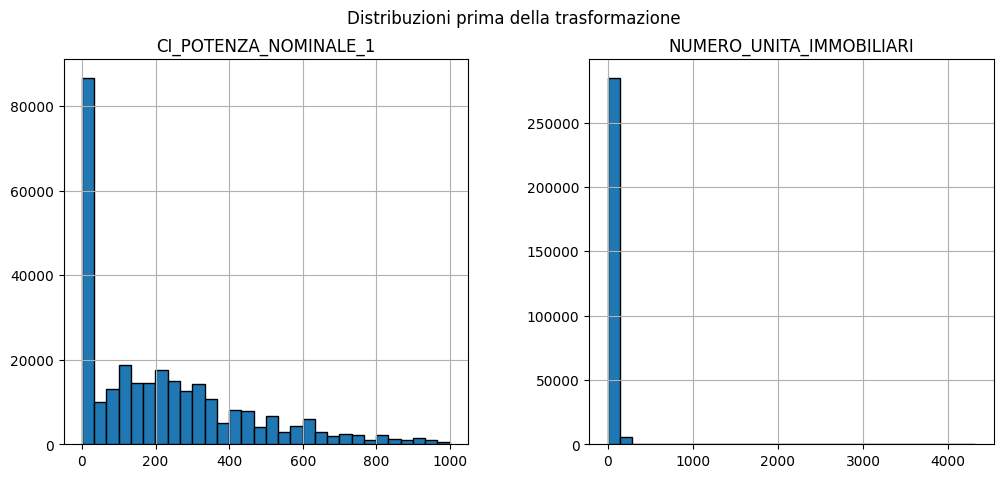

Valori di Fare uguali a zero: 0


In [17]:
import matplotlib.pyplot as plt

# Selezioniamo le variabili continue per vedere se serve il log
cols_to_analyze = ['CI_POTENZA_NOMINALE_1', 'NUMERO_UNITA_IMMOBILIARI']

# Visualizziamo le distribuzioni
X_train[cols_to_analyze].hist(bins=30, figsize=(12, 5), layout=(1, 2), edgecolor='black')
plt.suptitle("Distribuzioni prima della trasformazione")
plt.show()

# Verifichiamo se Fare ha valori zero (il log(0) è -infinito)
print(f"Valori di Fare uguali a zero: {(X_train['NUMERO_UNITA_IMMOBILIARI'] == 0).sum()}")

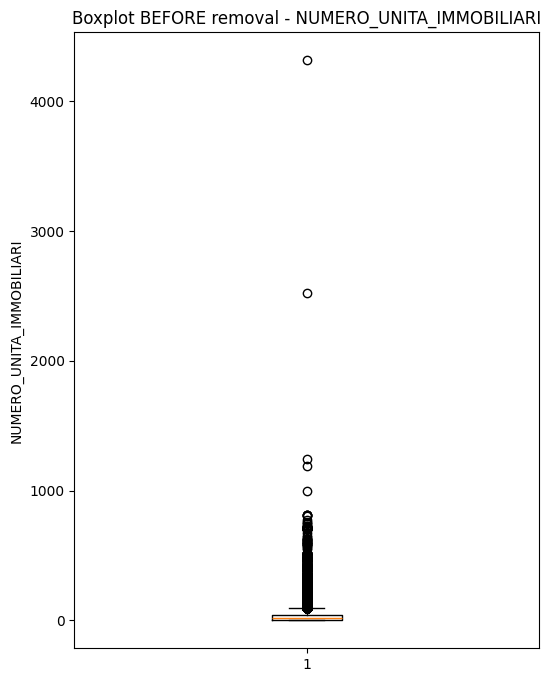

=== OUTLIER REPORT ===
Valori rimossi: 15398
Range outlier esclusi: min=99, max=4316
Boundaries: lower=-57.5, upper=98.5


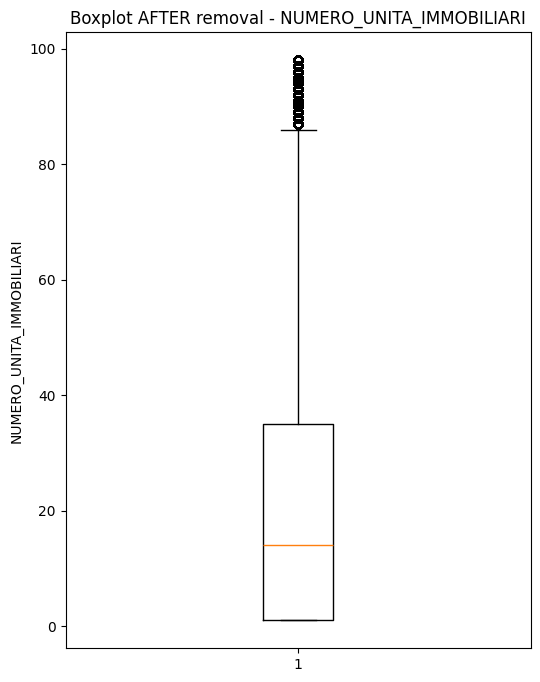

In [18]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

col = "NUMERO_UNITA_IMMOBILIARI"

# --- 1. Boxplot prima della rimozione ---
plt.figure(figsize=(6, 8))
plt.boxplot(X_train[col], vert=True)
plt.title(f"Boxplot BEFORE removal - {col}")
plt.ylabel(col)
plt.show()

# --- 2. Funzione per maschera outlier ---
def get_outlier_mask(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    mask = (df[col] < lower) | (df[col] > upper)
    return mask, lower, upper

# --- 3. Calcolo outlier ---
mask, lower_bound, upper_bound = get_outlier_mask(X_train, col)

outliers = X_train[mask][col]
before = len(X_train)

# --- 4. Rimozione outlier ---
X_train_clean = X_train[~mask]
y_train_clean = y_train.loc[X_train_clean.index]
after = len(X_train_clean)

# --- 5. Report ---
print("=== OUTLIER REPORT ===")
print(f"Valori rimossi: {before - after}")
print(f"Range outlier esclusi: min={outliers.min()}, max={outliers.max()}")
print(f"Boundaries: lower={lower_bound}, upper={upper_bound}")

# --- 6. Boxplot dopo la rimozione ---
plt.figure(figsize=(6, 8))
plt.boxplot(X_train_clean[col], vert=True)
plt.title(f"Boxplot AFTER removal - {col}")
plt.ylabel(col)
plt.show()

# --- 7. Aggiorna X_train e y_train ---
X_train = X_train_clean
y_train = y_train_clean


## NORMALIZZIAMO


In [19]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 275719 entries, 147098 to 208771
Data columns (total 38 columns):
 #   Column                                               Non-Null Count   Dtype  
---  ------                                               --------------   -----  
 0   RESIDENZIALE                                         275719 non-null  bool   
 1   NON_RESIDENZIALE                                     275719 non-null  bool   
 2   INTERO_EDIFICIO                                      275719 non-null  bool   
 3   UNITA_IMMOBILIARE                                    275719 non-null  bool   
 4   NUMERO_UNITA_IMMOBILIARI                             275719 non-null  int64  
 5   NUOVA_COSTRUZIONE                                    275719 non-null  bool   
 6   RISTRUTTURAZIONE_IMPORTANTE                          275719 non-null  bool   
 7   RIQUALIFICAZIONE_ENERGETICA                          275719 non-null  bool   
 8   ZONA_CLIMATICA                                       275719 non-n

In [ ]:
#  18  CI_ANNO_INSTALLAZIONE_1                              275719 non-null  float64
#  21  ANNO_COSTRUZIONE_NUM                                 275719 non-null  int64  

In [31]:
X_train["CI_EFFICIENZA_MEDIA"].head()

147098    0.61
341087    0.76
23095     1.26
93776     2.75
202280    0.79
Name: CI_EFFICIENZA_MEDIA, dtype: float64

In [32]:
from sklearn.preprocessing import StandardScaler

# 1. Definiamo le colonne da scalare
# Escludiamo le colonne binarie/OneHot (Sex e Embarked_*)
cols_to_scale = ['NUMERO_UNITA_IMMOBILIARI', 'SUPERF_UTILE_RISCALDATA','CI_EFFICIENZA_MEDIA', 'VOLUME_LORDO_RISCALDATO', 'SUPERFICIE_DISPERDENTE', 'RAPPORTO_SV', 'CI_POTENZA_NOMINALE_1']

# 2. Inizializziamo lo scaler
scaler = StandardScaler()

# 3. Fit & Transform su X_train
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])

# 4. Solo Transform su X_test (usando le statistiche del train!)
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

# Verifica finale: media vicina a 0, std vicina a 1 per il train
print("Verifica Standardizzazione (X_train):")
print(X_train[cols_to_scale].describe().loc[['mean', 'std']])

Verifica Standardizzazione (X_train):
      NUMERO_UNITA_IMMOBILIARI  SUPERF_UTILE_RISCALDATA  CI_EFFICIENZA_MEDIA  \
mean             -8.184723e-17            -2.700753e-17        -2.061643e-19   
std               1.000002e+00             1.000002e+00         1.000002e+00   

      VOLUME_LORDO_RISCALDATO  SUPERFICIE_DISPERDENTE   RAPPORTO_SV  \
mean             6.236471e-18           -1.561695e-17  2.454386e-16   
std              1.000002e+00            1.000002e+00  1.000002e+00   

      CI_POTENZA_NOMINALE_1  
mean           1.149366e-17  
std            1.000002e+00  


## MODELLO

In [41]:
cols_to_drop = ["CI_VETTORE_ENERGETICO_1_Carbone"]
X_test = X_test.drop(columns=cols_to_drop)

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 1. Inizializziamo il modello
# Utilizziamo il solver 'liblinear' che è ottimo per dataset piccoli
model = LogisticRegression(solver='liblinear', random_state=42)

# 2. Addestramento
model.fit(X_train, y_train)

# 3. Predizione
y_pred = model.predict(X_test)

# 4. Valutazione
print(f"Accuracy del modello: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy del modello: 0.8685

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92     55470
           1       0.82      0.57      0.68     17395

    accuracy                           0.87     72865
   macro avg       0.85      0.77      0.80     72865
weighted avg       0.86      0.87      0.86     72865



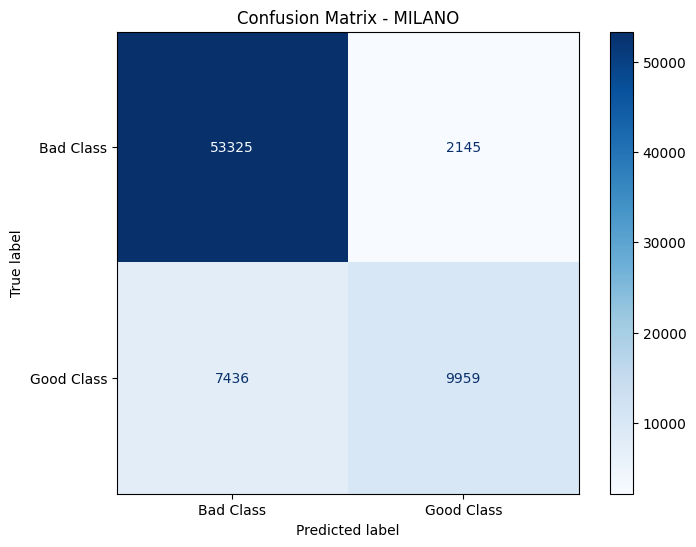

In [43]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Bad Class', 'Good Class'])
disp.plot(cmap=plt.cm.Blues, ax=ax)

plt.title('Confusion Matrix - MILANO')
plt.show()